# Set Up

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load Data Set

In [9]:
df = pd.read_csv("DATA/PROCESSED/streaming_titles_clustered.csv")

print(df.shape)
df.head()

(96200, 78)


,genre_names,origin_country,engagement_score,original_language,popularity_norm,genre_ids,title_age,tmdb_id,freshness_score,original_title,...,topic_animation_family,topic_friendship,topic_revenge,topic_road_trip_journey,topic_school_university,topic_work_business,topic_diversity_score,kmeans_cluster,cluster_label,engage_vis_cluster
0,"Crime, Drama, Comedy",US,7.789985,English,0.916136,"[80, 18, 35]",8.0,79744.0,0.922481,The Rookie,...,0,0,0,0,0,1,3,3,High Visibility,0
1,"Action, Science Fiction, Thriller",AU,2.340317,English,1.000000,"[28, 878, 53]",0.0,1265609.0,0.984496,War Machine,...,0,0,0,0,0,0,4,3,High Visibility,0
2,Drama,US,27.603475,English,0.796415,[18],21.0,1416.0,0.821705,Grey's Anatomy,...,0,0,0,0,0,0,0,3,High Visibility,0
3,"Drama, Mystery, Sci-Fi & Fantasy",US,21.134389,English,0.830130,"[18, 9648, 10765]",21.0,1622.0,0.821705,Supernatural,...,0,0,0,0,0,0,5,3,High Visibility,0
4,"Sci-Fi & Fantasy, Drama, Action & Adventure",US,67.621359,English,0.445930,"[10765, 18, 10759]",15.0,1399.0,0.868217,Game of Thrones,...,0,0,0,0,0,0,4,2,High Visibility,0


Purpose

The regression model answers:
- “Can we predict the Business Value Score based on content features?”

This is a supervised learning approach, where the model learns from known outcomes.


# Define Features

1. Define Features and Target

X (features):
- popularity
- vote_count
- vote_average
- release_year
- runtime
- topic features

y (target):
- business_value_score

This defines what the model learns from and what it predicts.

In [10]:
topic_cols = [col for col in df.columns if col.startswith("topic_")]

features = [
    "popularity",
    "vote_count",
    "vote_average",
    "release_year",
    "runtime_final",
    "visibility_score",
    "engagement_score",
    "audience_reception_score",
    "topic_diversity_score"
] 

target = "business_value_score"

# Prepare Data

Missing values were filled to ensure a complete dataset for training.

In [11]:
X = df[features].copy()
y = df[target]

# Fill missing values
X = X.fillna(0)
y = y.fillna(y.median())

# Train / Test Split

We split the dataset into:
- Training set → used to train the model
- Test set → used to evaluate performance

This ensures the model can generalize to unseen data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 76960
Test set size: 19240


# Linear Regression

We first used a simple linear regression model.

Purpose:
- establish a baseline
- test if relationships are approximately linear
- provide interpretability


In [13]:
# Train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)



# Evaluate Linear Reegression

RSME = AVG prediction error

R^2 = how much variance i explain (closer to 1 better)

These metrics help evaluate how well the model performs.

In [14]:
# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MSE: {mse_lr}")
print(f"Linear Regression R²: {r2_lr}")

Linear Regression MSE: 1.048677660138843
Linear Regression R²: 0.8136700173096019


The model achieved an R² score of 0.81, which means it explains approximately 81% of the variance in the target variable. This indicates a strong predictive performance.

The Mean Squared Error (MSE) is 1.05, which represents the average squared difference between predicted and actual values. Taking the square root, the RMSE is approximately 1.02, meaning that on average, the model's predictions deviate from the true values by about 1 unit.

Overall, the model performs well and captures most of the underlying patterns in the data.


# Random Forest

We then trained a Random Forest model.


 Why?
Because relationships between variables are often non-linear, for example:
- popularity may not increase value linearly
- interactions between variables matter


Random Forest captures these complex relationships better.


In [15]:
# Train the Random Forest model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MSE: {mse_rf}")
print(f"Random Forest R²: {r2_rf}")

Random Forest MSE: 0.030953522518751254
Random Forest R²: 0.9945001504901304


The Random Forest model achieved an R² score of 0.99, meaning it explains approximately 99.45% of the variance in the target variable. This indicates extremely high predictive performance.

The Mean Squared Error (MSE) is 0.031, and the corresponding RMSE is approximately 0.18, suggesting that predictions are, on average, very close to the actual values.

While this performance appears excellent, such a high R² may indicate potential overfitting, meaning the model could be capturing noise or memorizing the training data rather than generalizing well to unseen data.


# Feature Importance 

We extracted feature importance from the Random Forest model.

This tells us:

“Which variables drive business value the most?”

Examples:
- popularity
- engagement
- ratings
- thematic diversity


In [19]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

#print(feature_importance_df)
print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10))


Top 10 Most Important Features:
                    Feature  Importance
2              vote_average    0.368906
7  audience_reception_score    0.194386
3              release_year    0.166983
1                vote_count    0.125019
0                popularity    0.107036
5          visibility_score    0.022612
6          engagement_score    0.013787
8     topic_diversity_score    0.000701
4             runtime_final    0.000571


plot feature importance 

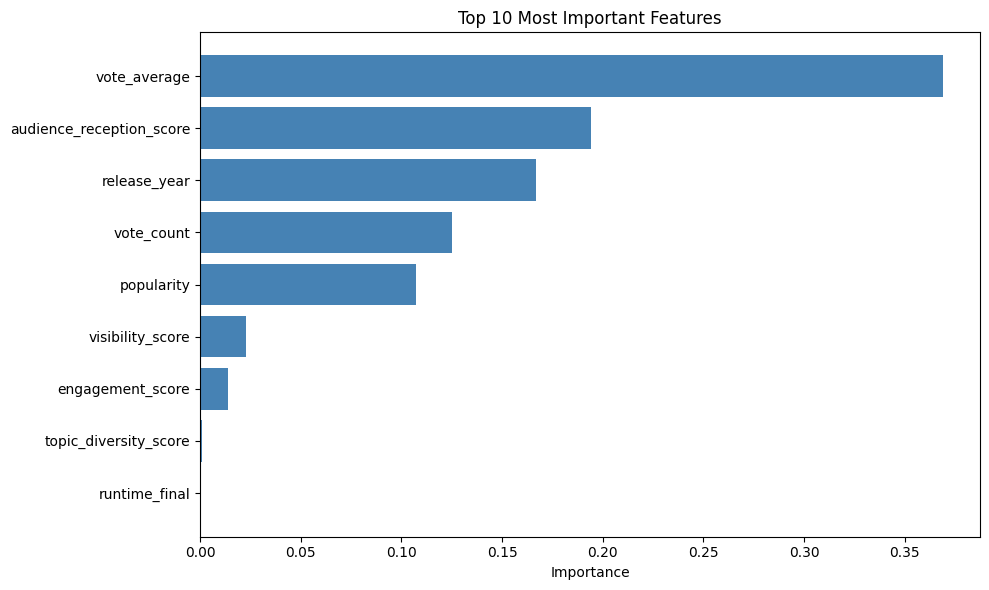

In [20]:
import matplotlib.pyplot as plt

top10 = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1], color="steelblue")
plt.xlabel("Importance")
plt.title("Top 10 Most Important Features")
plt.tight_layout()
plt.show()

The feature importance analysis shows that vote_average is by far the most influential variable, contributing approximately 37% of the model's decision-making process.

This is followed by audience_reception_score, release_year, and vote_count, which also have significant contributions.

Lower-ranked features such as visibility_score, engagement_score, and topic_diversity_score have minimal impact on the model's predictions.


# Compare predictions vs Real

We generated predicted business value scores for all titles.

This allows:
- comparison between actual vs predicted values
- simulation of new content performance

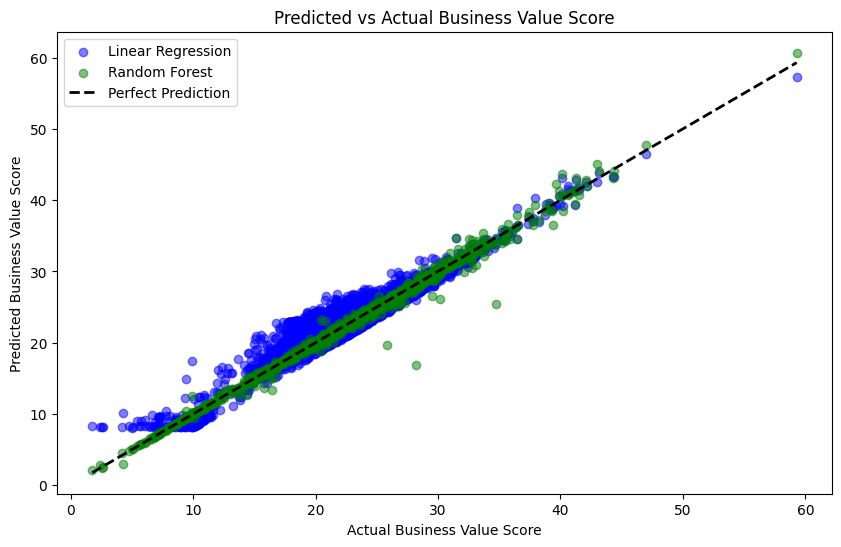

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, label='Linear Regression', color='blue')
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='Random Forest', color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Business Value Score')
plt.ylabel('Predicted Business Value Score')
plt.title('Predicted vs Actual Business Value Score')
plt.legend()
plt.show()

The scatter plot compares predicted vs actual values for both Linear Regression and Random Forest models.

The dashed diagonal line represents perfect predictions.

The Random Forest model (green) closely follows the diagonal, indicating highly accurate predictions with minimal error.

In contrast, the Linear Regression model (blue) shows greater dispersion around the line, suggesting higher prediction errors and less precision.

Overall, Random Forest significantly outperforms Linear Regression in capturing the underlying patterns of the data.


# Save Random Forest prediction Model

In [22]:
import joblib

# Save the trained Random Forest model to a file for business value prediction
joblib.dump(rf_model, 'MODELS/rf_model.pkl')

['MODELS/rf_model.pkl']

# Predict business value score with new content 

In [23]:
import joblib

# Load the saved Random Forest model (if not already in memory)
rf_model = joblib.load('MODELS/rf_model.pkl')

# Example new content features (replace with actual new data)
new_data = pd.DataFrame({
    'popularity': [100.0],
    'vote_count': [1000.0],
    'vote_average': [8.0],
    'release_year': [2023.0],
    'runtime_final': [120.0],
    'visibility_score': [80.0],
    'engagement_score': [50.0],
    'audience_reception_score': [85.0],
    'topic_diversity_score': [3]
})

# Predict business value score for the new content
predicted_business_value = rf_model.predict(new_data)
print(f"Predicted Business Value Score: {predicted_business_value[0]}")

Predicted Business Value Score: 45.212657721656186


We built a regression model to predict the Business Value Score using POPULARUTY, VOTE COUNT, VOTE AVERAGE, RELEASE YEAR, RUN TIME FINAL, VISIBILITY SCORE, ENGAGEMENT SCORE, AUDIENCE RECEPTION SCORE and TOPIC DIVERSITY SCORE